<a href="https://colab.research.google.com/github/BekkozhaAyana/Ayana-Project/blob/main/Ninja_Turtles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PHASE 1 - Web Scraping

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import logging

# Configuring logging to track progress and debug network issues during the long scraping process
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(message)s',
    filename='parsing_log.txt',
    filemode='w'
)
class FinalFastScraper:
    def __init__(self, target_count=5500):
        self.base_url = "https://www.goodreads.com/list/show/1.Best_Books_Ever"
        self.target_count = target_count
        # Using a session object for connection pooling and better performance
        self.session = requests.Session()
        self.headers = {
            "User-Agent": "SDS106-StudentProject/1.0 (zhanerke@sdu.edu.kz)",
            "Accept-Language": "en-US,en;q=0.9"
        }
        self.data = []

    def scrape(self):
        page = 1
        while len(self.data) < self.target_count:
            logging.info(f"Page: {page}. colllected: {len(self.data)}/5500")

            try:
                # Increased timeout to handle slow server responses during bulk requests
                response = self.session.get(
                    f"{self.base_url}?page={page}",
                    headers=self.headers,
                    timeout=60
                )

                if response.status_code == 429:
                    logging.warning("Rate limit hit. Ждем 2 минуты...")
                    time.sleep(120)
                    continue

                if response.status_code != 200:
                    logging.error(f"Error {response.status_code}. Try next page.")
                    page += 1
                    continue

                soup = BeautifulSoup(response.text, 'html.parser')
                books = soup.find_all('tr', itemtype="http://schema.org/Book")

                if not books: break

                for book in books:
                    if len(self.data) >= self.target_count: break
                    try:
                        title_tag = book.find('a', class_='bookTitle')
                        rating_raw = book.find('span', class_='minirating').text.strip().replace(',', '')
                        parts = rating_raw.split(' — ')

                        # Parsing unstructured text into 8 distinct data columns
                        self.data.append({
                            "title": title_tag.text.strip(),
                            "author": book.find('a', class_='authorName').text.strip(),
                            "avg_rating": parts[0].replace(' avg rating', '').strip(),
                            "total_ratings": parts[1].replace(' ratings', '').strip(),
                            "list_score": book.find('span', class_='smallText uitext').find('a').text.replace('score: ', '').replace(',', '').strip(),
                            "list_votes": book.find('span', class_='smallText uitext').find_all('a')[1].text.replace(' people voted', '').replace(',', '').strip(),
                            "book_url": "https://www.goodreads.com" + title_tag['href'],
                            "scrape_timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
                        })
                    except: continue

                # Intermediate data backup to prevent loss during network failures
                if page % 5 == 0:
                    pd.DataFrame(self.data).to_csv("goodreads_step.csv", index=False, encoding='utf-8-sig')

                page += 1
                # Ethical delay to mimic human behavior and respect server resources
                time.sleep(random.uniform(2.5, 4.5))

            except (requests.exceptions.ReadTimeout, requests.exceptions.ConnectTimeout):
                logging.error(f"Timeout on page {page}. Wait 10 seconds and try again...")
                time.sleep(10)
                continue
            except Exception as e:
                logging.error(f"Unexpected error: {e}")
                time.sleep(5)
                page += 1

        df = pd.DataFrame(self.data)
        df.to_csv("goodreads_final_5500.csv", index=False, encoding='utf-8-sig')
        logging.info("--- The collection is completed! ---")



if __name__ == "__main__":
    scraper = FinalFastScraper()
    scraper.scrape()

ERROR:root:Timeout on page 1. Wait 10 seconds and try again...
ERROR:root:Timeout on page 5. Wait 10 seconds and try again...
ERROR:root:Timeout on page 10. Wait 10 seconds and try again...
ERROR:root:Timeout on page 43. Wait 10 seconds and try again...


#PHASE 2 - Data Cleaning & Transformation

In [2]:
import pandas as pd
import numpy as np
from scipy import stats

try:
    df_raw = pd.read_csv("goodreads_final_5500.csv")
except FileNotFoundError:
    print("Error: File not found. Please check the path to your CSV.")
    exit()

before_count = len(df_raw)

df = df_raw.copy()

for col in ['title', 'author']:
    df[col] = df[col].astype(str).str.lower().str.strip()

before_dupes = df.duplicated(subset=['title', 'author']).sum()

df = df.drop_duplicates(subset=['title', 'author'])

cols_to_numeric = ['avg_rating', 'total_ratings', 'list_score', 'list_votes']
df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')

df[['list_score', 'list_votes']] = df[['list_score', 'list_votes']].fillna(0)

df = df.dropna(subset=['title', 'avg_rating', 'total_ratings'])


#  OUTLIER HANDLING (Statistical Methods: IQR & Z-Score)
Q1 = df['total_ratings'].quantile(0.25)
Q3 = df['total_ratings'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df['z_score_rating'] = np.abs(stats.zscore(df['avg_rating']))

df['is_outlier'] = (df['total_ratings'] > upper_bound) | (df['z_score_rating'] > 3)

df['pop_idx'] = (df['list_score'] / (df['list_votes'] + 1)).round(2)

# Binning books into categorical buckets based on their reach/popularity
df['rating_bucket'] = pd.cut(df['total_ratings'],
                             bins=[-1, 5000, 50000, 500000, np.inf],
                             labels=['Niche', 'Mainstream', 'Popular', 'Blockbuster'])

# Dropping temporary calculation columns and saving the final cleaned dataset
df_final = df.drop(columns=['z_score_rating'])
df_final.to_csv("goodreads_cleaned.csv", index=False)

print(f"Initial rows: {before_count}")
print(f"Duplicates removed: {before_dupes}")
print("File 'goodreads_cleaned.csv' successfully saved.")

Initial rows: 5500
Duplicates removed: 85
File 'goodreads_cleaned.csv' successfully saved.


In [3]:
#TABLE BEFORE/AFTER

temp_df = df_raw.copy()
temp_df[cols_to_numeric] = temp_df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')
bad_rows_before = temp_df[['title', 'avg_rating', 'total_ratings']].isnull().any(axis=1).sum()

new_features_count = len(df_final.columns) - len(df_raw.columns)

# DATA INTEGRITY CHECK (POST-PROCESSING)
dupes_after = df.duplicated(subset=['title', 'author']).sum()
bad_rows_after = df[['title', 'avg_rating', 'total_ratings']].isnull().any(axis=1).sum()
outliers_after = df['is_outlier'].sum()

B = "\033[34m"
BR = "\033[1;34m"
RESET = "\033[0m"

# Generating a summary table to compare dataset state before and after cleaning
report = f"""
{BR}--- FINAL DATA WRANGLING REPORT ---{RESET}
{B}{'Metric':<30} | {'Before (Found)':<15} | {'After (Check)':<15}{RESET}
{B}{'-'*65}{RESET}
{B}{'Total Dataset Rows':<30} | {before_count:<15} | {len(df):<15}{RESET}
{B}{'Duplicate Records':<30} | {before_dupes:<15} | {dupes_after:<15}{RESET}
{B}{'Broken/Null Rows':<30} | {bad_rows_before:<15} | {bad_rows_after:<15}{RESET}
{B}{'-'*65}{RESET}
{B}{'Outliers Flagged':<30} | 0               | {outliers_after:<15}{RESET}
{B}{'New Features Created':<30} | 0               | {new_features_count:<15}{RESET}
"""

print(report)


--- FINAL DATA WRANGLING REPORT ---
Metric                         | Before (Found)  | After (Check)  
-----------------------------------------------------------------
Total Dataset Rows             | 5500            | 5331           
Duplicate Records              | 85              | 0              
Broken/Null Rows               | 85              | 0              
-----------------------------------------------------------------
Outliers Flagged               | 0               | 632            
New Features Created           | 0               | 3              



#Phase 3-4 Exploratory Data Analysis and Data Visualization

In [4]:

df['pop_idx'] = (df['list_score'] / (df['list_votes'] + 1)).round(2)

df['rating_bucket'] = pd.cut(df['total_ratings'],
                             bins=[0, 5000, 50000, 500000, np.inf],
                             labels=['Niche', 'Mainstream', 'Popular', 'Blockbuster'])

df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))

print("Available speakers:", df.columns.tolist())

Available speakers: ['title', 'author', 'avg_rating', 'total_ratings', 'list_score', 'list_votes', 'book_url', 'scrape_timestamp', 'z_score_rating', 'is_outlier', 'pop_idx', 'rating_bucket', 'title_word_count']


In [5]:
import pandas as pd

def compute_descriptive_stats(df):
    numeric_df = df.select_dtypes(include=['number'])

    stats = numeric_df.describe().T

    stats['mode'] = numeric_df.mode().iloc[0]

    stats['range'] = stats['max'] - stats['min']

    stats = stats.round(2)

    print("--- DESCRIPTIVE STATISTICS REPORT ---")
    print(stats[['count', 'mean', 'mode', 'std', 'min', '25%', '50%', '75%', 'max', 'range']])

    return stats

final_stats = compute_descriptive_stats(df)



--- DESCRIPTIVE STATISTICS REPORT ---
                   count       mean     mode        std      min       25%  \
avg_rating        5331.0       4.09     4.14       0.25     3.01      3.92   
total_ratings     5331.0  223957.81   187.00  548277.90    42.00  28576.50   
list_score        5331.0   25925.19  1127.00  141384.49  1025.00   1525.00   
list_votes        5331.0     288.91    15.00    1475.38    11.00     19.00   
z_score_rating    5331.0       0.80     0.21       0.60     0.01      0.30   
pop_idx           5331.0      80.08    79.00       9.83    47.12     73.16   
title_word_count  5331.0       5.62     5.00       3.36     1.00      3.00   

                       50%        75%          max        range  
avg_rating            4.10       4.27         4.98         1.97  
total_ratings     78524.00  196373.00  11577893.00  11577851.00  
list_score         2736.00    6487.50   4433274.00   4432249.00  
list_votes           33.00      81.00     45059.00     45048.00  
z_score

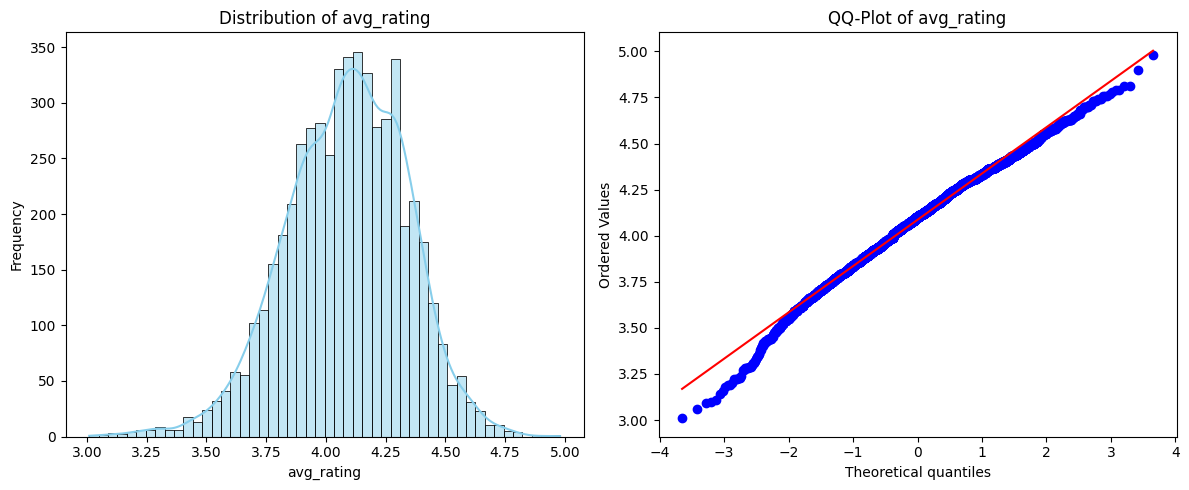

--- Statistics for avg_rating ---
Skewness (Asymmetry): -0.32
Shapiro-Wilk p-value: 0.0000
Conclusion: The distribution is statistically significantly different from normal.
------------------------------


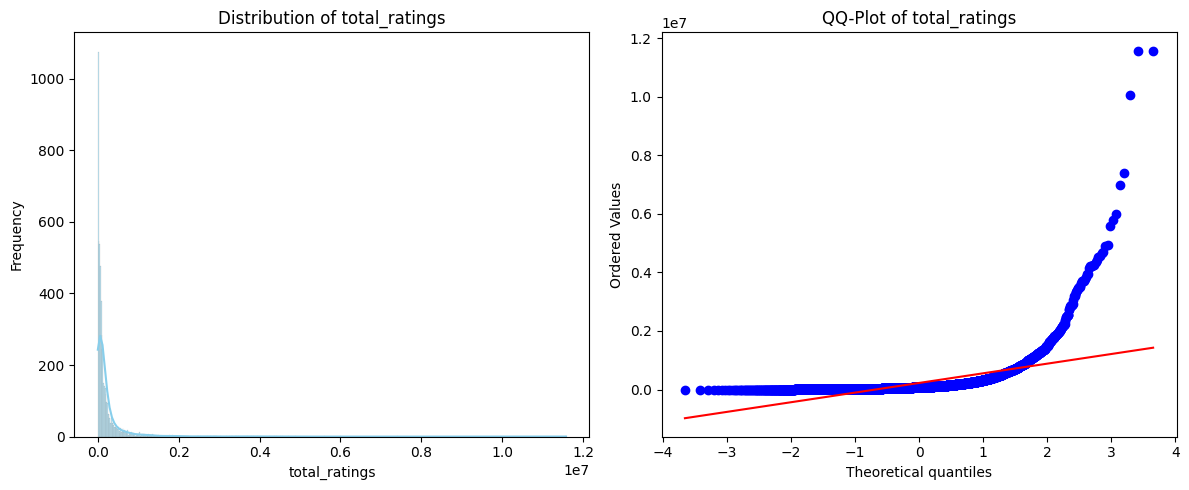

--- Statistics for total_ratings ---
Skewness (Asymmetry): 8.64
Shapiro-Wilk p-value: 0.0000
Conclusion: The distribution is statistically significantly different from normal.
------------------------------


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, shapiro

def analyze_distributions(df, columns):
    for col in columns:
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        sns.histplot(df[col], kde=True, color='skyblue')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')

        plt.subplot(1, 2, 2)
        from scipy import stats
        stats.probplot(df[col], dist="norm", plot=plt)
        plt.title(f'QQ-Plot of {col}')

        plt.tight_layout()
        plt.show()

        s = skew(df[col].dropna())
        k = kurtosis(df[col].dropna())

        # if p-value < 0.05, the distribution is NOT normal.
        stat, p_value = shapiro(df[col].dropna()[:5000])

        print(f"--- Statistics for {col} ---")
        print(f"Skewness (Asymmetry): {s:.2f}")
        print(f"Shapiro-Wilk p-value: {p_value:.4f}")

        if p_value > 0.05:
            print("Conclusion: The distribution is close to normal.")
        else:
            print("Conclusion: The distribution is statistically significantly different from normal.")
        print("-" * 30)

analyze_distributions(df, ['avg_rating', 'total_ratings'])

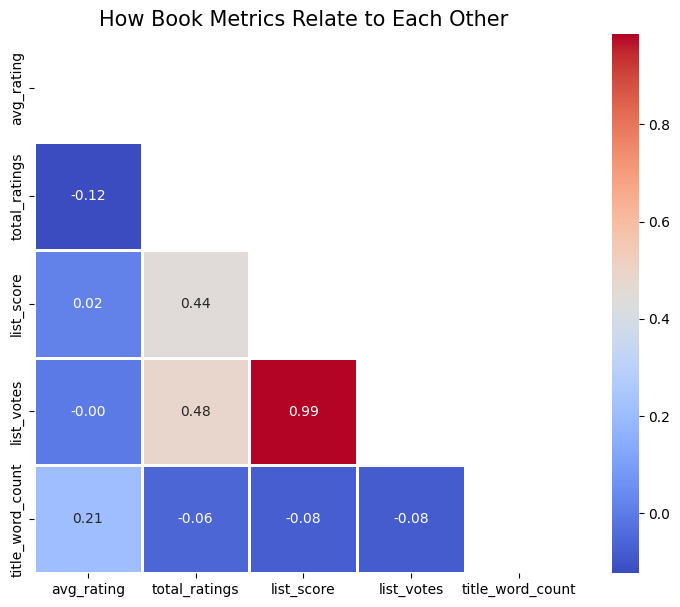

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def run_correlation_simple(df):
    columns_to_study = [
        'avg_rating',
        'total_ratings',
        'list_score',
        'list_votes',
        'title_word_count'
    ]
    # We use Spearman's method because it works best with book ratings.
    correlation_matrix = df[columns_to_study].corr(method='spearman')

    plt.figure(figsize=(10, 7))

    # We create a mask to avoid duplicating values ​​(remove the top triangle)
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

    sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', linewidths=1, square=True )

    plt.title('How Book Metrics Relate to Each Other', fontsize=15)
    plt.show()

run_correlation_simple(df)

**The "Descriptor Premium" Theory**

"We hypothesize that as the number of words in a title increases, the average rating also increases. This suggests that longer titles act as a quality filter, attracting a more targeted and satisfied audience."

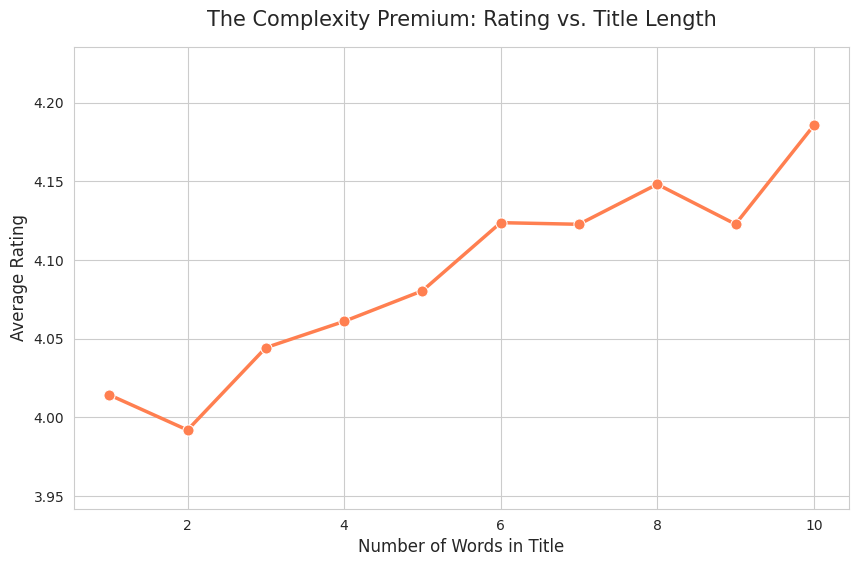

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
quality_trend = df[df['title_word_count'] <= 10].groupby('title_word_count')['avg_rating'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.lineplot(data=quality_trend, x='title_word_count', y='avg_rating',
             marker='o', markersize=8, color='coral', linewidth=2.5)

plt.title('The Complexity Premium: Rating vs. Title Length', fontsize=15, pad=15)
plt.xlabel('Number of Words in Title', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)

# Adjust the Y-axis limits to enhance visibility and emphasize the trends in the data
plt.ylim(quality_trend['avg_rating'].min() - 0.05, quality_trend['avg_rating'].max() + 0.05)

plt.show()

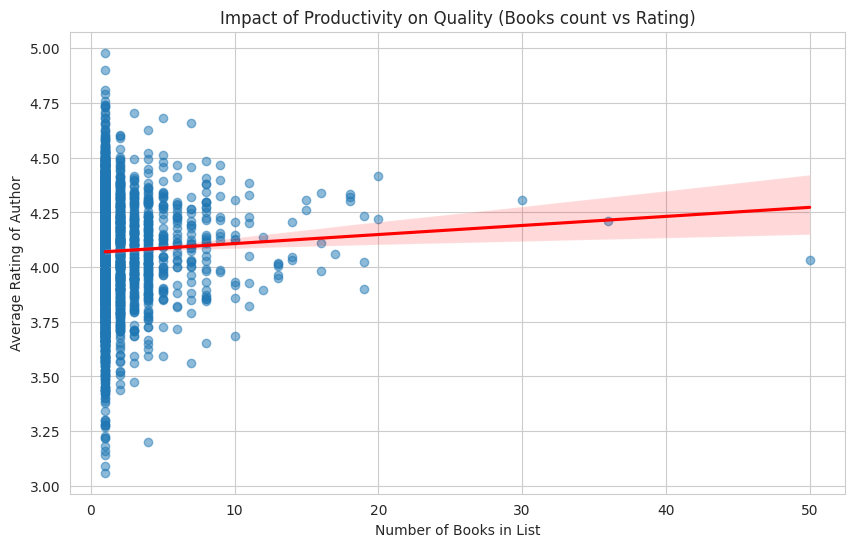

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_author_correlations(df):
    author_stats = df.groupby('author').agg({
        'avg_rating': 'mean',
        'total_ratings': 'sum',
        'list_score': 'sum',
        'title': 'count'
    }).rename(columns={'title': 'books_count'}).reset_index()

    plt.figure(figsize=(10, 6))
    sns.regplot(data=author_stats, x='books_count', y='avg_rating', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title('Impact of Productivity on Quality (Books count vs Rating)')
    plt.xlabel('Number of Books in List')
    plt.ylabel('Average Rating of Author')
    plt.show()

analyze_author_correlations(df)

**"The Survivor Bias & Brand Loyalty Hypothesis"**

"We hypothesize that an author's productivity positively correlates with their rating due to audience filtration. Authors with a large body of work (15+ books) build a dedicated fanbase that is already aligned with their style. This creates a positive feedback loop: as the author writes more, 'random' critics drop off, and only loyal followers remain, leading to higher and more stable average ratings."

In [10]:

author_analysis = df.groupby('author').agg({
    'title': 'count',
    'avg_rating': 'mean',
    'total_ratings': 'sum'
}).rename(columns={'title': 'book_count'})

top_authors = author_analysis.nlargest(10, 'total_ratings')

print("--- Top 10 Authors by Total Popularity ---")
display(top_authors)

author_stats = df.groupby('author').agg({
    'avg_rating': 'mean',
    'total_ratings': 'sum',
    'title': 'count'
}).rename(columns={'title': 'books_in_list'})

popular_authors = author_stats[author_stats['total_ratings'] > 10000]


--- Top 10 Authors by Total Popularity ---


,book_count,avg_rating,total_ratings
author,,,
j.k. rowling,18,4.332222,51725493
sarah j. maas,16,4.338750,31497285
colleen hoover,19,4.025263,22552039
suzanne collins,7,4.265714,20831806
stephen king,50,4.034200,17052560
stephenie meyer,11,3.821818,15472668
rick riordan,30,4.305000,14521626
taylor jenkins reid,6,4.203333,13164873
j.r.r. tolkien,8,4.381250,11249036


In [11]:
import plotly.express as px

authors_data = df.groupby('author').agg({
    'total_ratings': 'sum',
    'avg_rating': 'mean',
    'title': 'count'
}).reset_index().nlargest(30, 'total_ratings')

fig1 = px.treemap(authors_data,
                 path=['author'],
                 values='total_ratings',
                 color='avg_rating',
                 hover_data=['title'],
                 color_continuous_scale='YlGn',
                 title='Top 30 Authors: Market Share vs. Average Rating')

fig1.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig1.show()

--- Group-by Statistics ---
  rating_bucket  avg_rating     list_score  book_count
0         Niche    4.213980    3299.431438         598
1    Mainstream    4.081364    4983.247067        1364
2       Popular    4.057510   10675.150265        2835
3   Blockbuster    4.109719  185717.134831         534


/tmp/ipykernel_2182/4001722274.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




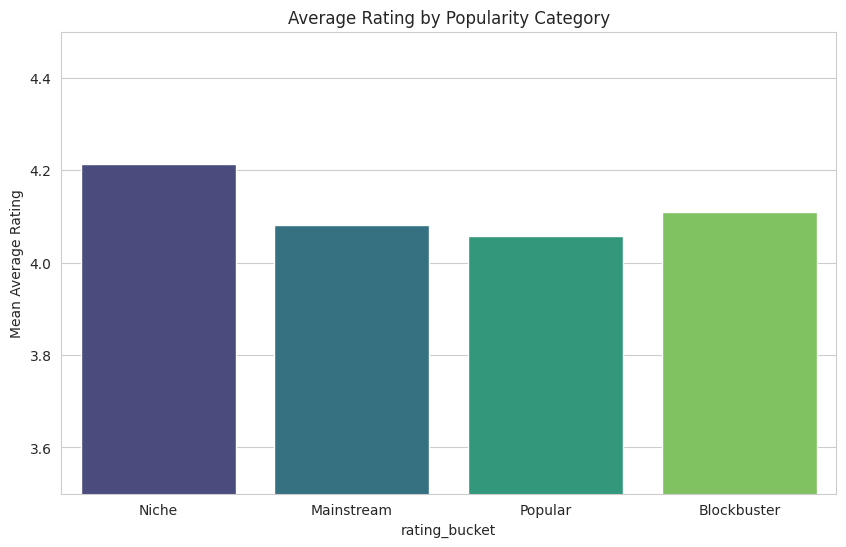

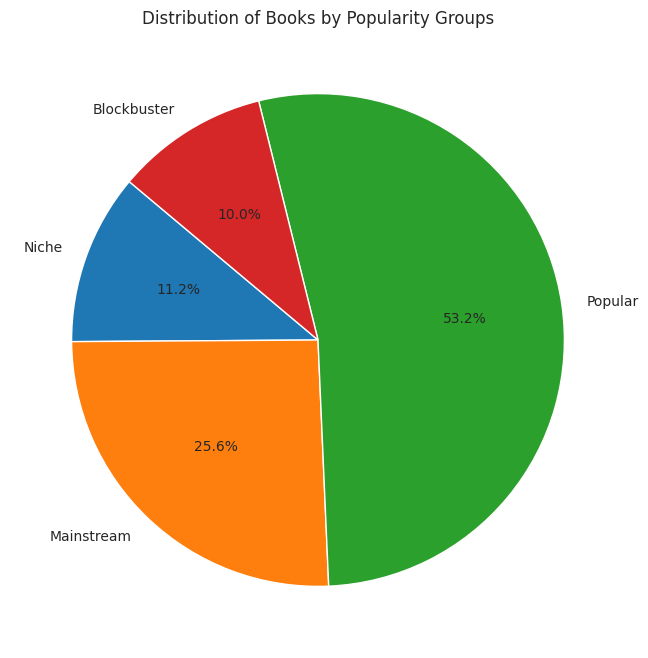

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def perform_groupby_analysis(df):
    group_stats = df.groupby('rating_bucket', observed=True).agg({
        'avg_rating': 'mean',
        'list_score': 'mean',
        'total_ratings': 'count'
    }).rename(columns={'total_ratings': 'book_count'}).reset_index()

    print("--- Group-by Statistics ---")
    print(group_stats)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=group_stats, x='rating_bucket', y='avg_rating', palette='viridis')
    plt.title('Average Rating by Popularity Category')
    plt.ylabel('Mean Average Rating')
    plt.ylim(3.5, 4.5)
    plt.show()

    plt.figure(figsize=(8, 8))
    plt.pie(group_stats['book_count'], labels=group_stats['rating_bucket'], autopct='%1.1f%%', startangle=140)
    plt.title('Distribution of Books by Popularity Groups')
    plt.show()

perform_groupby_analysis(df)

**"The Matthew Effect in Literature: Success Breeds Success"**

"We hypothesize that book popularity follows a cumulative advantage pattern, known as the Matthew Effect. High visibility and a massive number of existing reviews act as powerful social proof, creating a self-reinforcing loop. Instead of popularity diluting the score, it 'cements' it: readers approach high-profile books with a positive bias, leading to higher sustained average ratings compared to less-known titles."

In [13]:
import pandas as pd

top_10_score = df.nlargest(10, 'list_score')[['title', 'author', 'list_score', 'avg_rating']]

top_10_votes = df.nlargest(10, 'total_ratings')[['title', 'author', 'total_ratings', 'avg_rating']]

bottom_10_outliers = df[df['total_ratings'] > 5000].nsmallest(10, 'avg_rating')[['title', 'author', 'total_ratings', 'avg_rating']]

bottom_10_list_score = df[df['list_score'] > 1000].nsmallest(10, 'avg_rating')[['title', 'author', 'list_score', 'avg_rating']]

print("--- TOP 10 BOOKS BY LIST SCORE ---")
display(top_10_score)

print("\n--- TOP 10 MOST BY TOTAL RATINGS ---")
display(top_10_votes)

print("\n--- OUTLIER ANALYSIS: LOWEST RATED POPULAR BOOKS ---")
display(bottom_10_outliers)



--- TOP 10 BOOKS BY LIST SCORE ---


,title,author,list_score,avg_rating
0,"the hunger games (the hunger games, #1)",suzanne collins,4433274,4.35
1,pride and prejudice,jane austen,3024847,4.30
2,to kill a mockingbird,harper lee,2635088,4.26
3,harry potter and the order of the phoenix (har...,j.k. rowling,2106299,4.50
4,the book thief,markus zusak,1998396,4.39
5,"twilight (twilight saga, #1)",stephenie meyer,1782271,3.68
6,animal farm,george orwell,1750177,4.02
7,j.r.r. tolkien 4-book boxed set: the hobbit an...,j.r.r. tolkien,1687353,4.62
8,the chronicles of narnia (the chronicles of na...,c.s. lewis,1548690,4.28
9,the fault in our stars,john green,1434753,4.12



--- TOP 10 MOST BY TOTAL RATINGS ---


,title,author,total_ratings,avg_rating
70,harry potter and the philosopher's stone (harr...,j.k. rowling,11577893,4.47
110,harry potter and the sorcerer's stone (harry p...,j.k. rowling,11577893,4.47
0,"the hunger games (the hunger games, #1)",suzanne collins,10064624,4.35
5,"twilight (twilight saga, #1)",stephenie meyer,7395916,3.68
2,to kill a mockingbird,harper lee,6983260,4.26
19,the great gatsby,f. scott fitzgerald,6009667,3.93
9,the fault in our stars,john green,5789312,4.12
35,1984,george orwell,5589040,4.20
57,harry potter and the prisoner of azkaban (harr...,j.k. rowling,4927536,4.58
1,pride and prejudice,jane austen,4892345,4.30



--- OUTLIER ANALYSIS: LOWEST RATED POPULAR BOOKS ---


,title,author,total_ratings,avg_rating
830,"not forever, but for now",chuck palahniuk,5167,3.01
3523,the 120 days of sodom,marquis de sade,15205,3.06
2357,the house in the pines,ana reyes,200457,3.09
4204,the fever,megan abbott,26891,3.10
2019,the turnout,megan abbott,24066,3.11
4092,mein kampf,adolf hitler,43851,3.18
4809,imperial bedrooms,bret easton ellis,21113,3.20
2301,the death of jane lawrence,caitlin starling,23823,3.22
3973,snuff,chuck palahniuk,67382,3.22
5158,melania and me,stephanie winston wolkoff,8174,3.22


**"Popularity vs. True Appreciation."**

 We hypothesize that books recognized by the dedicated community (High List Score) will have higher average ratings than those that are simply famous (High Total Ratings). Mass-market fame often leads to lower ratings because when everyone reads a book, more people are likely to be disappointed.

In [14]:
import plotly.express as px
import pandas as pd

elite = df.nlargest(100, 'list_score').copy()
elite['Category'] = 'Community Elite (Top List Score)'

mass_market = df.nlargest(100, 'total_ratings').copy()
mass_market['Category'] = 'Mass Market (Top Total Ratings)'

comparison_df = pd.concat([elite, mass_market])

fig = px.box(comparison_df, x="Category", y="avg_rating",  color="Category",
    points="all", # Show all points (books) near the box
    hover_name="title",
    hover_data={
        "author": True,
        "avg_rating": ":.2f",
        "total_ratings": ",",
        "Category": False # Removing category repetition
        },
    title="The 'Hype Penalty' Test: Community Elite vs. Mass Market",
    color_discrete_map={'Community Elite (Top List Score)': '#2E8B57', 'Mass Market (Top Total Ratings)': '#FFA500'  })

fig.update_layout(
    yaxis_title="Average Rating",
    xaxis_title="",
    showlegend=False,
    template="plotly_white",
    hoverlabel=dict(bgcolor="white", font_size=12)
)

fig.show()

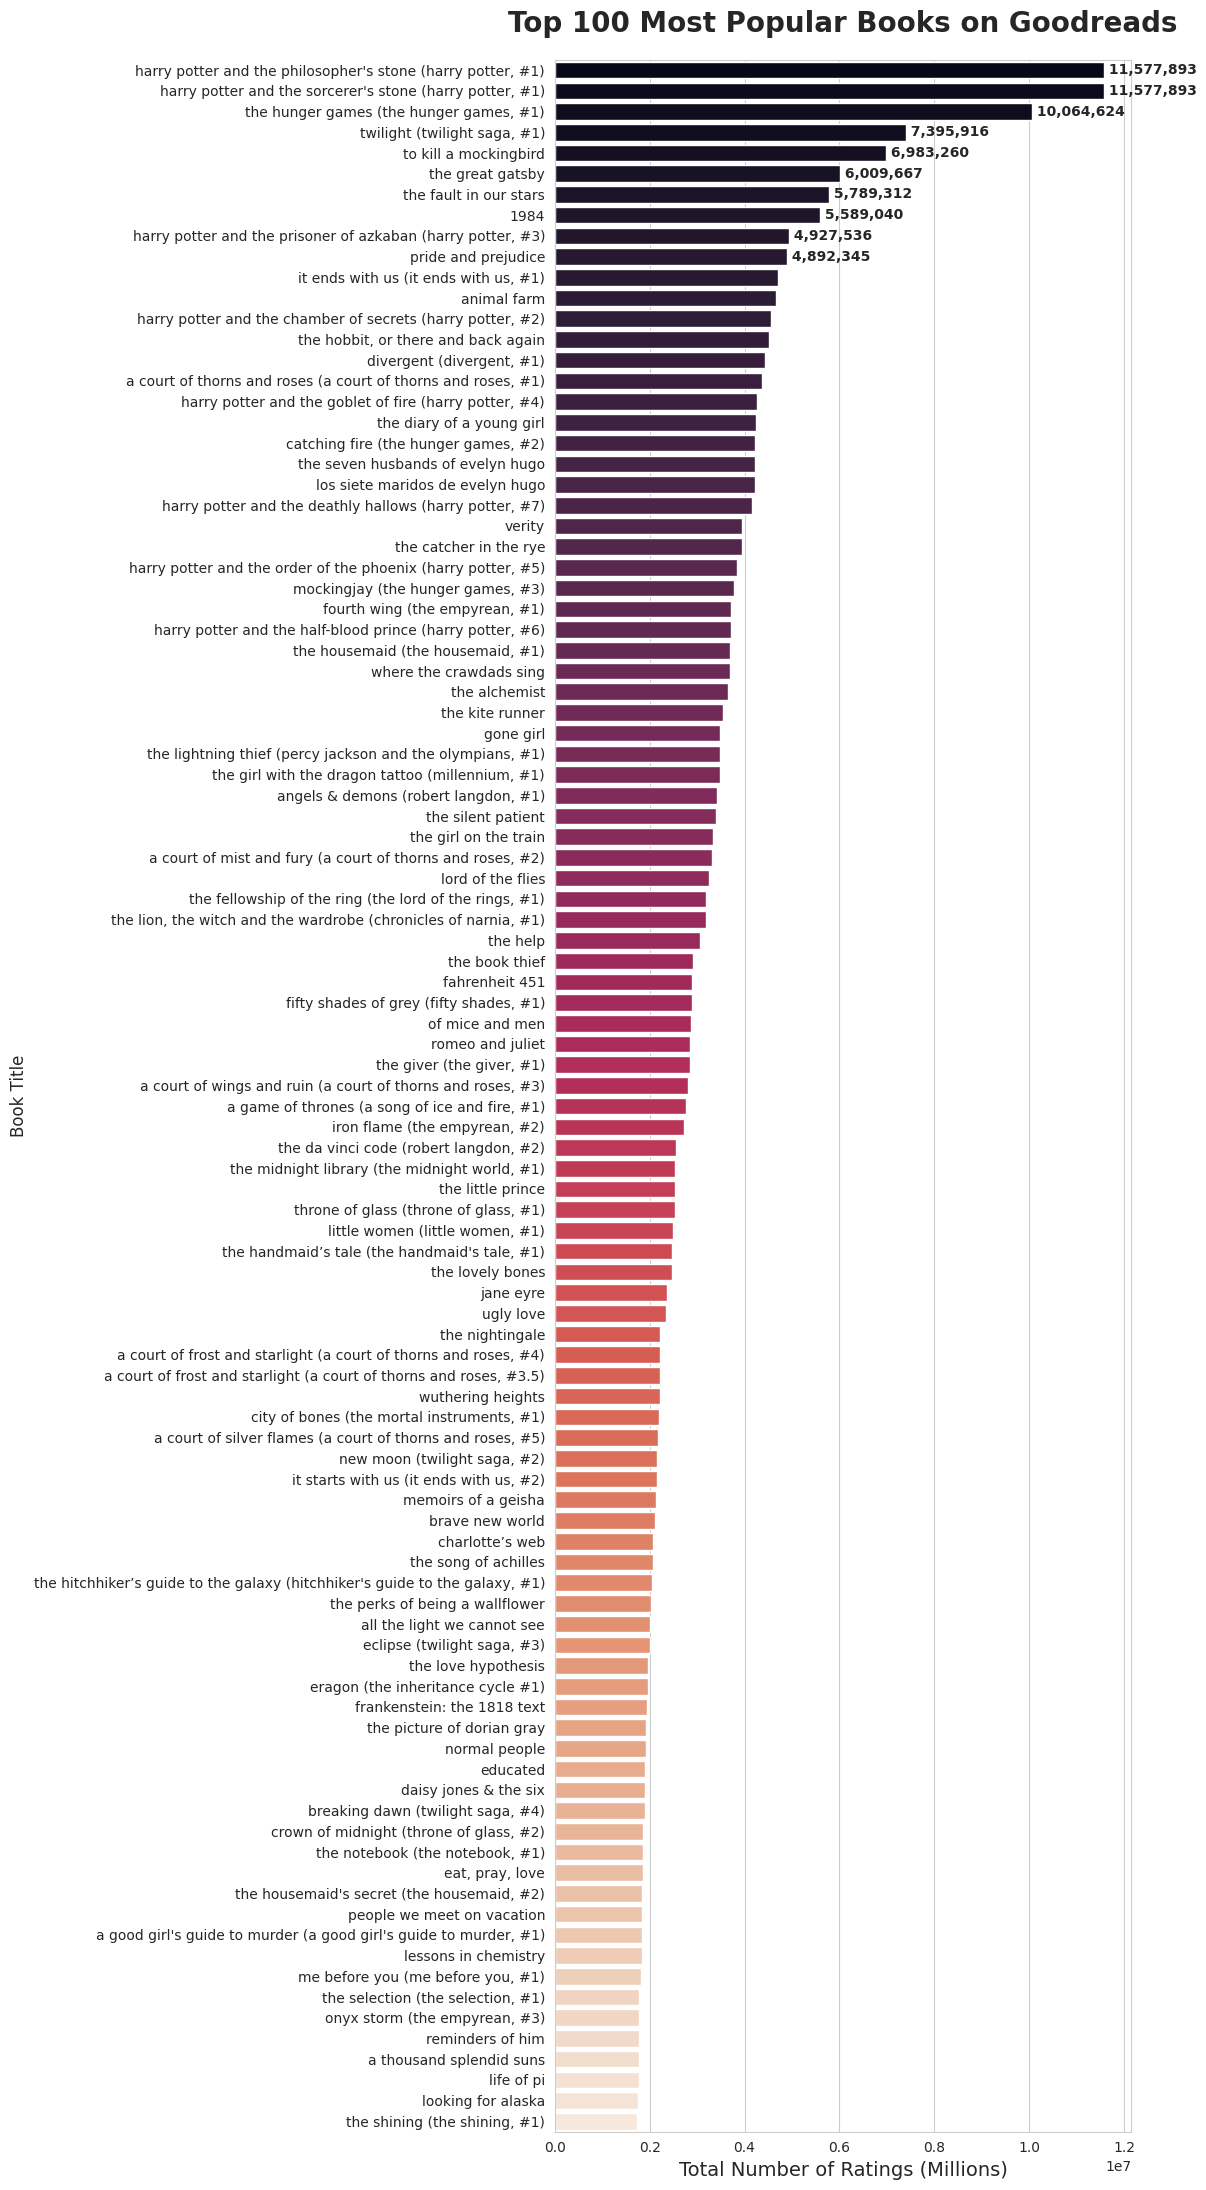

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('goodreads_cleaned.csv')

# 2. Get the Top 100 books by total ratings
top_100 = df.nlargest(100, 'total_ratings').copy()

# 3. Setup the visual style
plt.figure(figsize=(12, 22))  # Tall figure to ensure titles are readable
sns.set_style("whitegrid")

# 4. Create Horizontal Bar Chart
# We use the 'rocket' palette to show the "heat" of popularity
plot = sns.barplot(
    data=top_100,
    y='title',
    x='total_ratings',
    palette='rocket',
    hue='title',
    legend=False
)

# 5. Formatting the labels and titles
plt.title('Top 100 Most Popular Books on Goodreads', fontsize=20, weight='bold', pad=20)
plt.xlabel('Total Number of Ratings (Millions)', fontsize=14)
plt.ylabel('Book Title', fontsize=12)

# Optional: Adding value labels on the bars for the top 10
for i in range(10):
    value = top_100.iloc[i]['total_ratings']
    plt.text(value, i, f' {value:,.0f}', va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

#BONUS POINT


In [23]:
import requests
import time
import logging
import random
import pandas as pd
import re
from bs4 import BeautifulSoup

APP_ID = "b534248f"
APP_KEY = "0261dbfd008b59ccc3d45bb0b4b6a343"
RESULTS_PER_PAGE = 50
TARGET_RECORDS = 4000
OUTPUT_FILE = "adzuna_jobs_balanced.csv"

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler()]
)

def clean_text(raw_html):

    if not raw_html:
        return ""
    # 1. Strip HTML tags to extract clean text content
    text = BeautifulSoup(raw_html, "html.parser").get_text(separator=' ')
    # 2. Remove special characters and redundant whitespaces to clean the string format
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

class JobAPIScraper:
    def __init__(self, app_id, app_key):
        self.app_id = app_id
        self.app_key = app_key
        self.data = []

    def fetch_jobs(self, page):
        url = f"https://api.adzuna.com/v1/api/jobs/us/search/{page}"
        params = {
            'app_id': self.app_id,
            'app_key': self.app_key,
            'results_per_page': RESULTS_PER_PAGE,
            'what': 'python developer',
            'content-type': 'application/json'
        }
        try:
            response = requests.get(url, params=params, timeout=15)
            if response.status_code == 200:
                return response.json()
            return None
        except Exception as e:
            logging.error(f"Network error: {e}")
            return None

    def start_scraping(self):
        current_page = 1
        while len(self.data) < TARGET_RECORDS:
            logging.info(f"Progress: {len(self.data)}/{TARGET_RECORDS}. Page Request {current_page}...")
            result = self.fetch_jobs(current_page)

            if result and 'results' in result:
                jobs = result['results']
                if not jobs: break

                for job in jobs:
                    if len(self.data) >= TARGET_RECORDS: break

                    # Extract and perform immediate data sanitization
                    title = clean_text(job.get("title"))
                    company = job.get("company", {}).get("display_name")

                    # Skip corrupted or malformed records to maintain data integrity
                    if not title or not company:
                        continue

                    record = {
                        "title": title,
                        "company": company,
                        "location": job.get("location", {}).get("display_name"),
                        "description": clean_text(job.get("description")),
                        "salary_min": job.get("salary_min"),
                        "category": job.get("category", {}).get("label"),
                        "source": "Adzuna"
                    }
                    self.data.append(record)

                # Save intermediate results to prevent data loss during processing
                pd.DataFrame(self.data).to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
                current_page += 1
                time.sleep(random.uniform(1, 2))
            else:
                time.sleep(5)

        logging.info(f"Ready! File: {OUTPUT_FILE} contains {len(self.data)} clean records.")

if __name__ == "__main__":
    scraper = JobAPIScraper(APP_ID, APP_KEY)
    scraper.start_scraping()

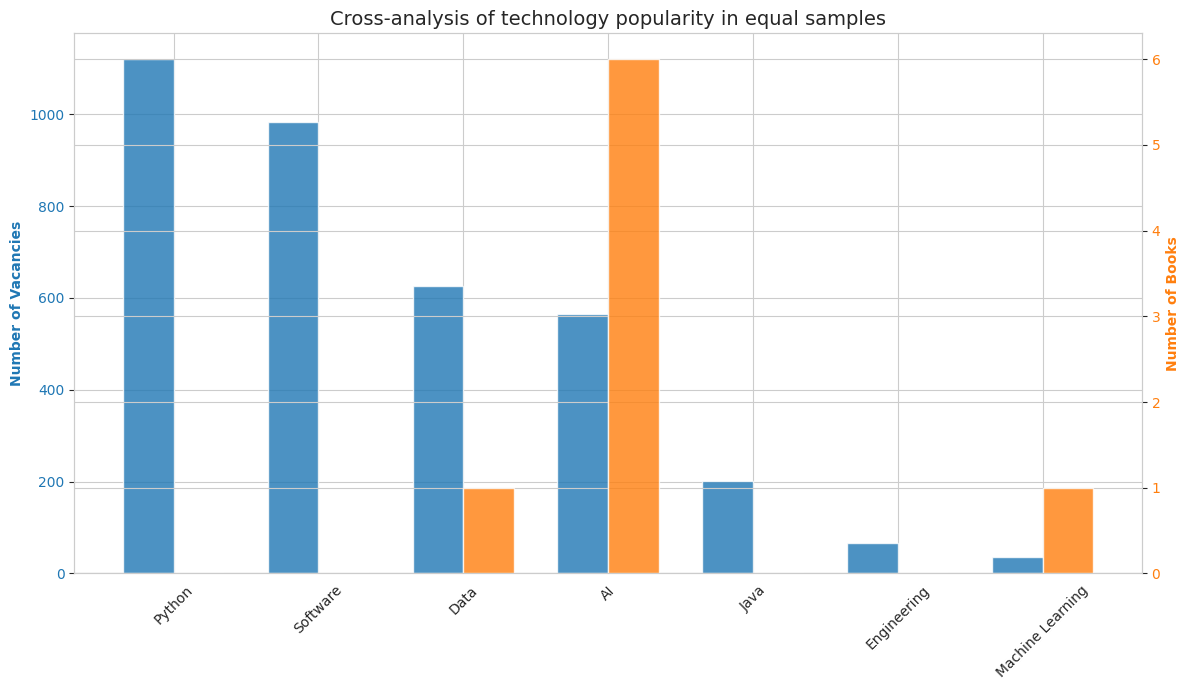


--- DATA PROTECTION ---
Selection of vacancies: 4000 | Selection of books: 4000
         Keyword  Jobs  Books
          Python  1120      0
        Software   982      0
            Data   626      1
              AI   566      6
            Java   201      0
     Engineering    66      0
Machine Learning    36      1


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

# 1. Loading exactly 2500 rows per file
# (Ensure that the file naming convention is followed strictly)
df_jobs = pd.read_csv('adzuna_jobs_balanced.csv', nrows=4000)
df_books = pd.read_csv('goodreads_final_5500.csv', nrows=4000)

# 2. Basic title cleaning (removing redundant whitespaces to improve lookup accuracy)
df_jobs['title'] = df_jobs['title'].str.strip()
df_books['title'] = df_books['title'].str.strip()

keywords = ['Python', 'Java', 'Data', 'AI', 'Machine Learning', 'Software', 'Engineering']

def count_in_df(df, col):
    counts = {}
    for kw in keywords:
        pattern = r'\b' + re.escape(kw) + r'\b'
        counts[kw] = df[col].str.contains(pattern, case=False, na=False).sum()
    return counts

# Calculate occurrences and frequencies
job_stats = count_in_df(df_jobs, 'title')
book_stats = count_in_df(df_books, 'title')

# Consolidate results into a structured dataframe
df_final = pd.DataFrame({
    'Keyword': keywords,
    'Jobs': [job_stats[k] for k in keywords],
    'Books': [book_stats[k] for k in keywords]
}).sort_values(by='Jobs', ascending=False)

# 3. beautiful graph
fig, ax1 = plt.subplots(figsize=(12, 7))
x = np.arange(len(keywords))
width = 0.35

ax1.bar(x - width/2, df_final['Jobs'], width, label='Vacancies (Adzuna)', color='#1f77b4', alpha=0.8)
ax1.set_ylabel('Number of Vacancies', color='#1f77b4', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

ax2 = ax1.twinx()
ax2.bar(x + width/2, df_final['Books'], width, label='Books (Goodreads)', color='#ff7f0e', alpha=0.8)
ax2.set_ylabel('Number of Books', color='#ff7f0e', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

ax1.set_xticks(x)
ax1.set_xticklabels(df_final['Keyword'], rotation=45)
plt.title('Cross-analysis of technology popularity in equal samples', fontsize=14)
fig.tight_layout()

plt.show()

print("\n--- DATA PROTECTION ---")
print(f"Selection of vacancies: {len(df_jobs)} | Selection of books: {len(df_books)}")
print(df_final.to_string(index=False))

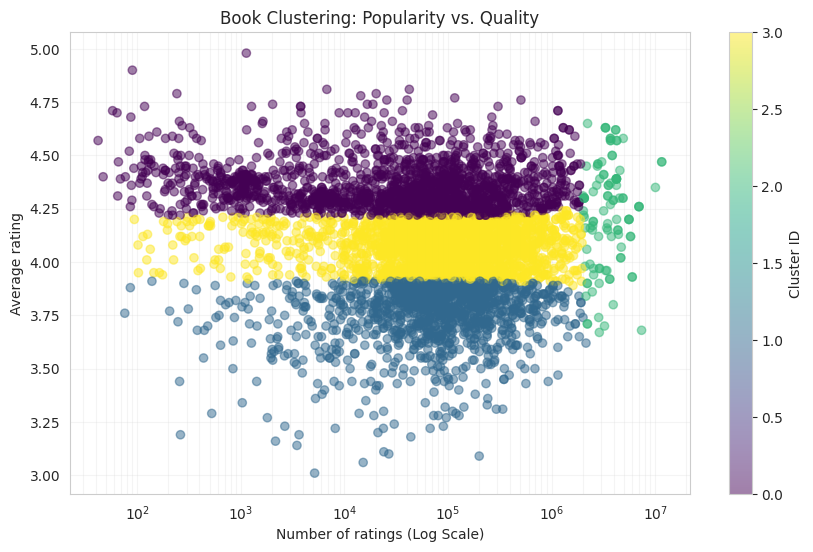

Average indicators by cluster:
         total_ratings  avg_rating
cluster                           
0         1.617864e+05    4.359430
1         1.677216e+05    3.753465
2         3.808088e+06    4.225660
3         2.037805e+05    4.071430


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. DATA LOADING
df = pd.read_csv('goodreads_final_5500.csv')

# 2. DATA CLEANING
# Convert ratings to numeric format and remove rows with missing essential metrics
df['avg_rating'] = pd.to_numeric(df['avg_rating'], errors='coerce')
df_clean = df.dropna(subset=['avg_rating', 'total_ratings']).copy()

# 3. FEATURE PREPARATION
# Selecting popularity (total_ratings) and quality (avg_rating) for analysis
X = df_clean[['total_ratings', 'avg_rating']]

# Feature scaling is mandatory as K-Means is sensitive to the magnitude of values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. K-MEANS MODELING
# Segmenting the dataset into 4 logical groups based on the scaled features
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

# 5. RESULTS VISUALIZATION
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_clean['total_ratings'],
    df_clean['avg_rating'],
    c=df_clean['cluster'],
    cmap='viridis',
    alpha=0.5
)

# Using a logarithmic scale for the X-axis due to the extreme variance in ratings (100 to 10M+)
plt.xscale('log')
plt.xlabel('Number of ratings (Log Scale)')
plt.ylabel('Average rating')
plt.title('Book Clustering: Popularity vs. Quality')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

# 6. Cluster profiling: Calculating mean metrics to define the identity of each segment
print("Average indicators by cluster:")
print(df_clean.groupby('cluster')[['total_ratings', 'avg_rating']].mean())

In [19]:
pip install streamlit plotly pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 102.4 MB/s eta 0:00:00


In [20]:
import streamlit as st
import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Page configuration for a professional wide-layout dashboard
st.set_page_config(page_title="Goodreads Analytics Dashboard", layout="wide")

@st.cache_data
def load_data():
    # Efficiently caching the dataset to prevent reloading on every user interaction
    df = pd.read_csv('goodreads_final_5500.csv')
    df['avg_rating'] = pd.to_numeric(df['avg_rating'], errors='coerce')
    return df.dropna(subset=['avg_rating', 'total_ratings', 'list_score'])

df = load_data()

st.title("📚 Goodreads Books Analysis Dashboard")
st.markdown("Interactive report on book popularity and quality trends")

# --- Sidebar Filters ---
st.sidebar.header("Data Filtering")
min_rating = st.sidebar.slider("Minimum Rating Threshold", 0.0, 5.0, 3.5)
top_n = st.sidebar.number_input("Display Top N Books", 5, 100, 10)

filtered_df = df[df['avg_rating'] >= min_rating]

# --- Section 1: Key Performance Indicators (KPIs) ---
col1, col2, col3 = st.columns(3)
col1.metric("Total Books Processed", len(df))
col2.metric("Global Average Rating", round(df['avg_rating'].mean(), 2))
col3.metric("Highest Vote Count", f"{int(df['total_ratings'].max()):,}")

# --- Section 2: Machine Learning (K-Means Clustering) ---
st.header("🎯 Book Segmentation (K-Means Clustering)")
st.write("Grouping books into segments based on popularity and user ratings.")

# User-defined cluster count for dynamic machine learning exploration
n_clusters = st.slider("Select Number of Clusters", 2, 6, 4)

# Preparing features for real-time clustering
X = filtered_df[['total_ratings', 'avg_rating']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
filtered_df['Cluster'] = kmeans.fit_predict(X_scaled)
filtered_df['Cluster'] = filtered_df['Cluster'].astype(str)

# Interactive visualization using Plotly for deep data exploration
fig_cluster = px.scatter(
    filtered_df,
    x="total_ratings",
    y="avg_rating",
    color="Cluster",
    hover_name="title",
    log_x=True,
    title="Popularity vs. Rating (Segmented by Clusters)",
    labels={"total_ratings": "Number of Ratings (log scale)", "avg_rating": "Average Rating"}
)
st.plotly_chart(fig_cluster, use_container_width=True)

# --- Section 3: High-Ranking Books ---
st.header(f"🏆 Top {top_n} Books by List Score")
top_books = filtered_df.sort_values('list_score', ascending=False).head(top_n)
st.table(top_books[['title', 'author', 'avg_rating', 'list_score']])

# --- Section 4: Author Lookup ---
st.header("🔍 Author Research Tool")
author_search = st.selectbox("Select or search for an author:", options=df['author'].unique())
author_df = df[df['author'] == author_search]
st.write(f"Works by {author_search} in this dataset:")
st.dataframe(author_df[['title', 'avg_rating', 'total_ratings']])

2026-04-26 10:34:38.043 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 10:34:38.046 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-26 10:34:38.048 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-26 10:34:38.049 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 10:34:38.099 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 10:34:38.515 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-26 10:34:38.516 Thread 'MainThread': mi

DeltaGenerator()

In [21]:
import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- DATA LOADING AND PREPARATION ---
df = pd.read_csv('goodreads_final_5500.csv')
# Ensure ratings are numeric and remove any incomplete records for clean visualization
df['avg_rating'] = pd.to_numeric(df['avg_rating'], errors='coerce')
df = df.dropna(subset=['avg_rating', 'total_ratings'])

# --- MACHINE LEARNING: CLUSTERING ---
# Selecting features: popularity (total_ratings) and quality (avg_rating)
X = df[['total_ratings', 'avg_rating']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applying K-Means to segment the books into 4 distinct groups
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled).astype(str)

fig = px.scatter(
    df, x="total_ratings", y="avg_rating", color="cluster",
    hover_name="title", log_x=True,
    title="Interactive Dashboard: Popularity vs. Rating",
    template="plotly_white"  # Professional dark theme for better data contrast
)

# --- EXPORT AND DISPLAY ---
# Save the interactive chart as a standalone HTML file for project presentations
fig.write_html("interactive_dashboard.html")
fig.show()

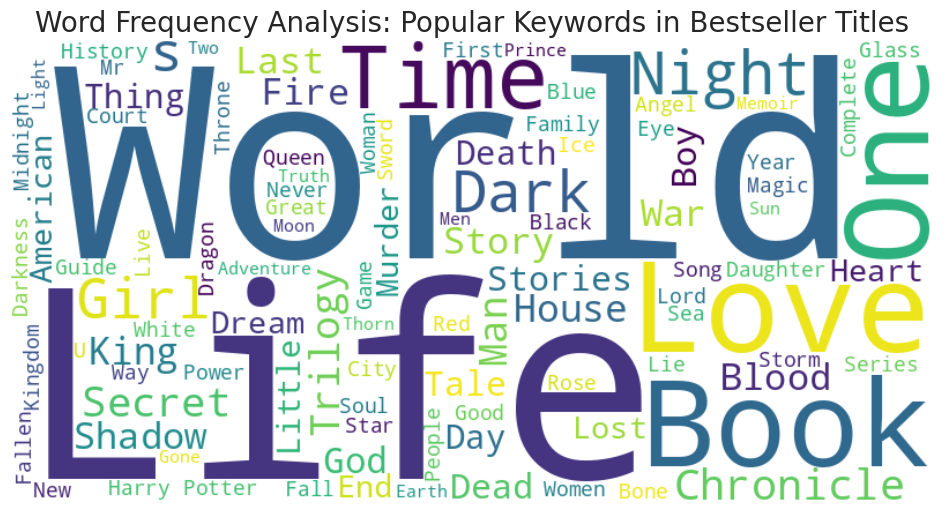

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(title for title in df.title.astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='viridis', max_words=100).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Frequency Analysis: Popular Keywords in Bestseller Titles", fontsize=20)
plt.show()